In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from utils import * 

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np

base = Path("clean_tables")
PRIMARY_KEY = "RowKey"

# 1. Load feature tables
sql_df    = pd.read_csv(base / "sql_metrics.csv")
static_df = pd.read_csv(base / "static_metrics.csv")
dynamic_df= pd.read_csv(base / "dynamic_metrics.csv")
graph_df = pd.read_csv(base / "graph_metrics.csv")
qiskit_df  = pd.read_csv(base / "qiskit_simulation.csv")
rdbms_df  = pd.read_csv(base / "rdbms_simulation.csv")

# 2. Merge feature tables first (numeric features)
feature_df = sql_df
# feature_df = sql_df.merge(static_df, on=PRIMARY_KEY, how="outer") \
#                        .merge(dynamic_df, on=PRIMARY_KEY, how="outer") \
#                        .merge(graph_df, on=PRIMARY_KEY, how="outer") \
# 3. FEATURES = numeric columns only (excluding PRIMARY_KEY)
FEATURES = feature_df.select_dtypes(include=[np.number]).columns.tolist()

# 4. Keep only memory_usage / execution_time columns
keep_suffixes = ["mb", "time_s"]
rdbms_cols = [PRIMARY_KEY] + [c for c in rdbms_df.columns if any(c.endswith(s) for s in keep_suffixes)]
rdbms_df = rdbms_df[rdbms_cols]

# 5. Merge feature_df with RDBMS columns to get final ML-ready df
df = feature_df.merge(rdbms_df, on=PRIMARY_KEY)
# Drop columns with nan in FEATURES
# Print initial number of rows
print("Initial rows before filtering automatic simulation:", len(df))
df = df.dropna(subset=FEATURES, how='any')
print("Rows after dropping NaNs in FEATURES:", len(df))

sim_cols = [c for c in rdbms_df.columns if c != PRIMARY_KEY]
df["at_least_one_sim"] = df[sim_cols].notna().any(axis=1)

print("Rows after filtering automatic simulation:", len(df))
print("Number of numeric feature columns:", len(FEATURES))
print("FEATURES sample:", FEATURES)


C:\Users\aadik\AppData\Local\Temp\ipykernel_23072\2026272784.py:13: DtypeWarning: Columns (40) have mixed types. Specify dtype option on import or set low_memory=False.
  qiskit_df  = pd.read_csv(base / "qiskit_simulation.csv")


Initial rows before filtering automatic simulation: 775
Rows after dropping NaNs in FEATURES: 775
Rows after filtering automatic simulation: 775
Number of numeric feature columns: 11
FEATURES sample: ['num_agg_funcs', 'num_and_clauses', 'num_subqueries_with', 'num_eq_predicates', 'num_group_bys', 'num_join_occurrences', 'num_joins', 'num_unique_join_edges', 'num_order_bys', 'num_select_columns', 'num_where_clauses']


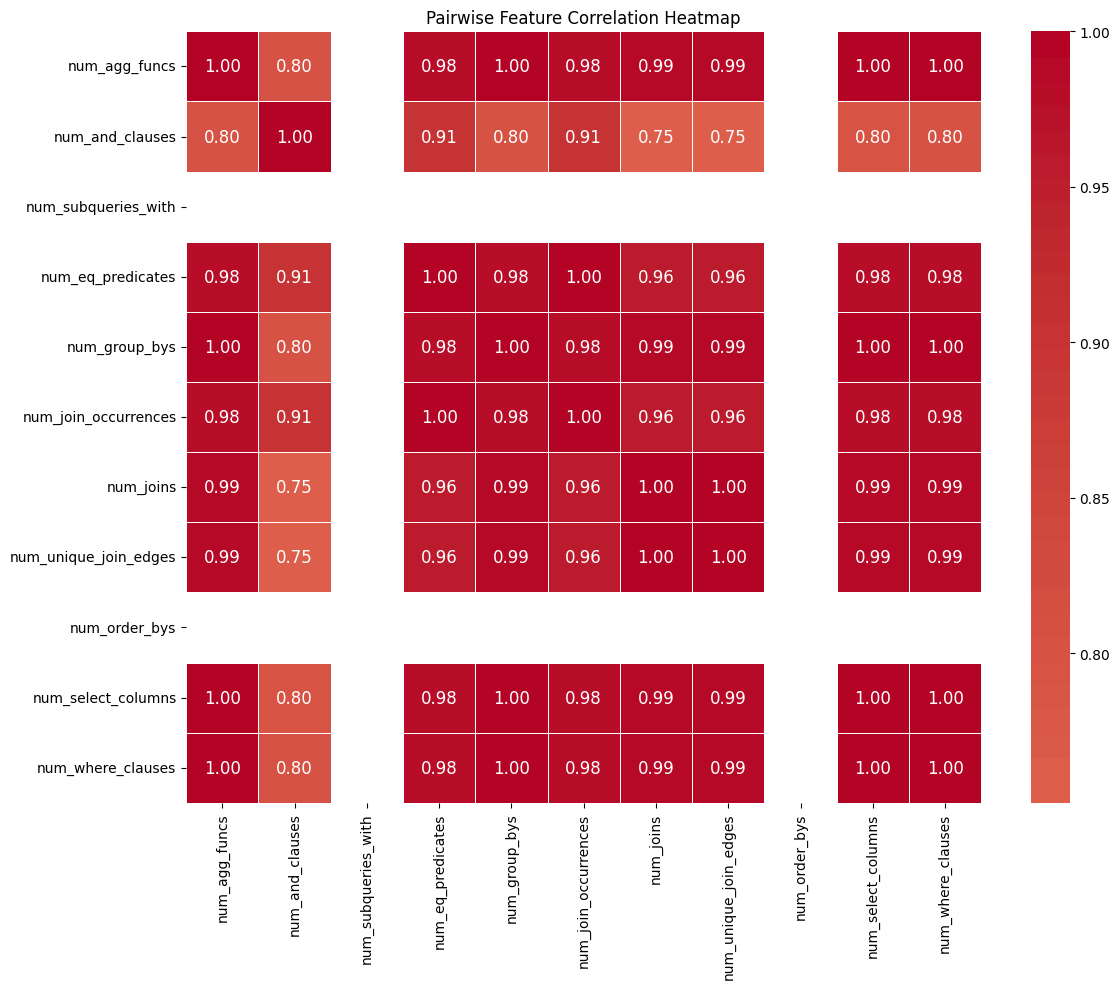

In [3]:
# Plot the correlation matrix using utils.PlotCorrelationMatrix
from utils import PlotCorrelationMatrix
pcm = PlotCorrelationMatrix(df, FEATURES, (12, 10))

Best execution time counts:
best_time_method
sqlite    681
Name: count, dtype: int64

Best memory usage counts:
best_mem_method
sqlite    681
Name: count, dtype: int64


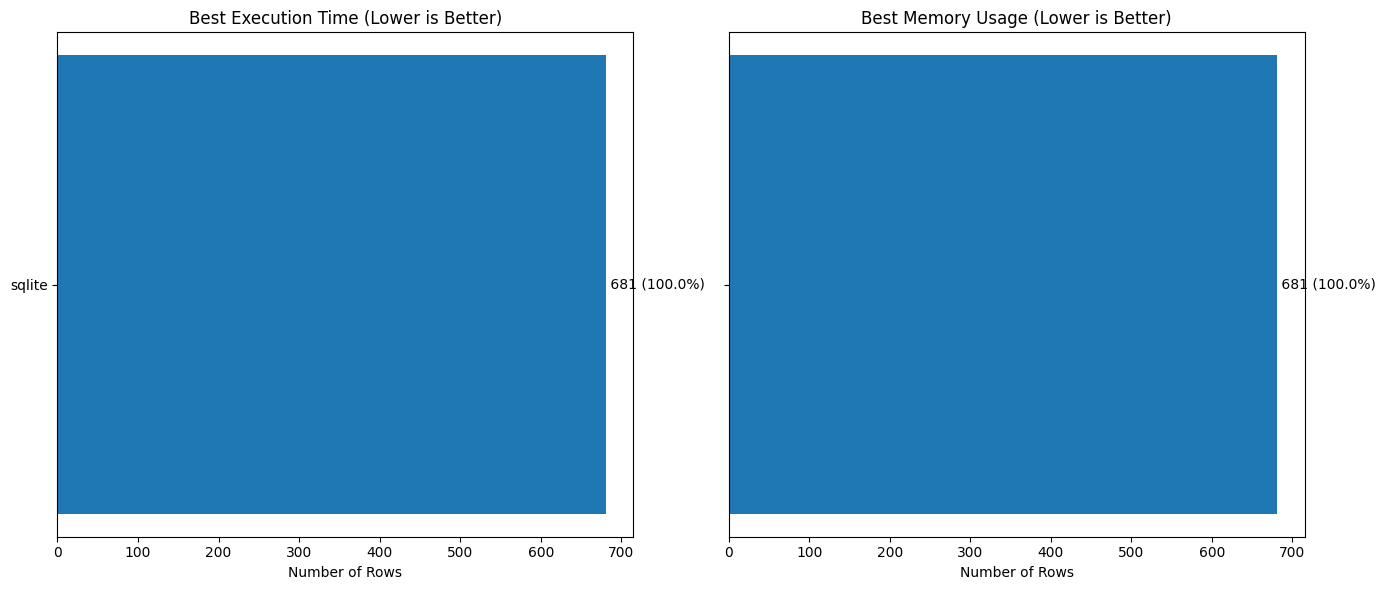

In [41]:
METHODS = [
    # "infiniquantum",
    # "psql",
    # "ducksql",
    "sqlite",
    # "np_mps",
    # "np_one_shot"
]
# These methods need to be in the column name to be that method. 

import matplotlib.pyplot as plt

# ----------------------------
# Identify metric columns
# ----------------------------
time_cols = {m: [c for c in df.columns if c.endswith("time_s") and m in c] for m in METHODS}
mem_cols  = {m: [c for c in df.columns if c.endswith("mb") and m in c] for m in METHODS}

# ----------------------------
# Determine best method per row
# ----------------------------
def best_method_per_row(row, col_map):
    values = {}
    for method, cols in col_map.items():
        if cols:
            values[method] = row[cols].min()
    values = {k: v for k, v in values.items() if pd.notna(v)}
    return min(values, key=values.get) if values else np.nan

df["best_time_method"] = df.apply(best_method_per_row, axis=1, col_map=time_cols)
df["best_mem_method"]  = df.apply(best_method_per_row, axis=1, col_map=mem_cols)

# ----------------------------
# Count wins
# ----------------------------
time_counts = df["best_time_method"].value_counts().reindex(METHODS, fill_value=0)
mem_counts  = df["best_mem_method"].value_counts().reindex(METHODS, fill_value=0)

print("Best execution time counts:")
print(time_counts)
print("\nBest memory usage counts:")
print(mem_counts)

# ----------------------------
# Plot 2×1 horizontal histogram
# ----------------------------

# ----------------------------
# Totals for percentage calc
# ----------------------------
time_total = time_counts.sum()
mem_total  = mem_counts.sum()

# ----------------------------
# Plot 1×2 horizontal histograms
# ----------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# ---- Execution time ----
axes[0].barh(time_counts.index, time_counts.values)
axes[0].set_title("Best Execution Time (Lower is Better)")
axes[0].set_xlabel("Number of Rows")

for i, (count, method) in enumerate(zip(time_counts.values, time_counts.index)):
    pct = 100 * count / time_total if time_total > 0 else 0
    axes[0].text(count, i, f" {count} ({pct:.1f}%)", va="center")

# ---- Memory usage ----
axes[1].barh(mem_counts.index, mem_counts.values)
axes[1].set_title("Best Memory Usage (Lower is Better)")
axes[1].set_xlabel("Number of Rows")

for i, (count, method) in enumerate(zip(mem_counts.values, mem_counts.index)):
    pct = 100 * count / mem_total if mem_total > 0 else 0
    axes[1].text(count, i, f" {count} ({pct:.1f}%)", va="center")

plt.tight_layout()
plt.show()




Best execution time counts:
best_time_method
sqlite                   71
density_matrix          233
matrix_product_state    439
extended_stabilizer      32
Name: count, dtype: int64

Best memory usage counts:
best_mem_method
sqlite                  272
density_matrix          110
matrix_product_state    196
extended_stabilizer     197
Name: count, dtype: int64


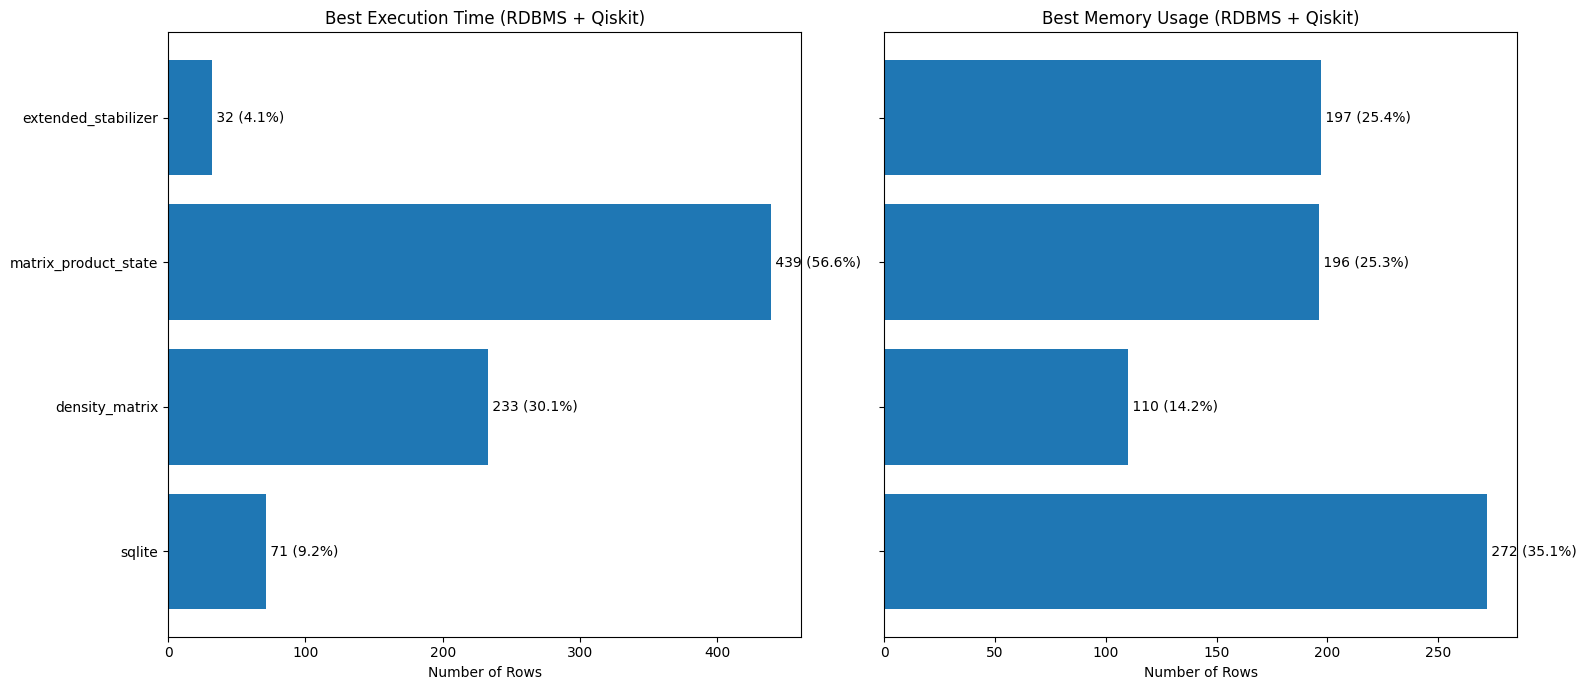

In [42]:
import matplotlib.pyplot as plt

# -------------------------------------------------
# Merge Qiskit results
# -------------------------------------------------
df_with_qiskit = df.merge(
    qiskit_df,
    on=PRIMARY_KEY,
    suffixes=("", "_qiskit")
)

# -------------------------------------------------
# Method definitions
# -------------------------------------------------
RDBMS_METHODS = METHODS

QISKIT_METHODS = [
    # "statevector_saved",
    "density_matrix",
    "matrix_product_state",
    "extended_stabilizer",
]

ALL_METHODS = RDBMS_METHODS + QISKIT_METHODS

# -------------------------------------------------
# Build column maps
# -------------------------------------------------
time_cols = {}
mem_cols = {}

# RDBMS
for m in RDBMS_METHODS:
    time_cols[m] = [c for c in df_with_qiskit.columns if c.endswith("time_s") and m in c]
    mem_cols[m]  = [c for c in df_with_qiskit.columns if c.endswith("mb") and m in c]

# Qiskit
for m in QISKIT_METHODS:
    time_cols[m] = [c for c in df_with_qiskit.columns if c.endswith("execution_time") and m in c]
    mem_cols[m]  = [c for c in df_with_qiskit.columns if c.endswith("memory_usage") and m in c]

# -------------------------------------------------
# Best method per row
# -------------------------------------------------
def best_method_per_row(row, col_map):
    values = {}
    for method, cols in col_map.items():
        if cols:
            v = row[cols].min()
            if pd.notna(v):
                values[method] = v
    return min(values, key=values.get) if values else np.nan

df_with_qiskit["best_time_method"] = df_with_qiskit.apply(
    best_method_per_row, axis=1, col_map=time_cols
)
df_with_qiskit["best_mem_method"] = df_with_qiskit.apply(
    best_method_per_row, axis=1, col_map=mem_cols
)

# -------------------------------------------------
# Count wins
# -------------------------------------------------
time_counts = (
    df_with_qiskit["best_time_method"]
    .value_counts()
    .reindex(ALL_METHODS, fill_value=0)
)

mem_counts = (
    df_with_qiskit["best_mem_method"]
    .value_counts()
    .reindex(ALL_METHODS, fill_value=0)
)

print("Best execution time counts:")
print(time_counts)
print("\nBest memory usage counts:")
print(mem_counts)

# -------------------------------------------------
# Plot 1×2 horizontal histograms with percentages
# -------------------------------------------------
time_total = time_counts.sum()
mem_total  = mem_counts.sum()

fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

# ---- Execution time ----
axes[0].barh(time_counts.index, time_counts.values)
axes[0].set_title("Best Execution Time (RDBMS + Qiskit)")
axes[0].set_xlabel("Number of Rows")

for i, count in enumerate(time_counts.values):
    pct = 100 * count / time_total if time_total else 0
    axes[0].text(count, i, f" {count} ({pct:.1f}%)", va="center")

# ---- Memory ----
axes[1].barh(mem_counts.index, mem_counts.values)
axes[1].set_title("Best Memory Usage (RDBMS + Qiskit)")
axes[1].set_xlabel("Number of Rows")

for i, count in enumerate(mem_counts.values):
    pct = 100 * count / mem_total if mem_total else 0
    axes[1].text(count, i, f" {count} ({pct:.1f}%)", va="center")

plt.tight_layout()
plt.show()


Random Forest        accuracy = 0.649
Decision Tree        accuracy = 0.567
Logistic Regression  accuracy = 0.521
Linear SVM           accuracy = 0.505
K-Nearest Neighbors  accuracy = 0.603
XGBoost Classifier   accuracy = 0.634


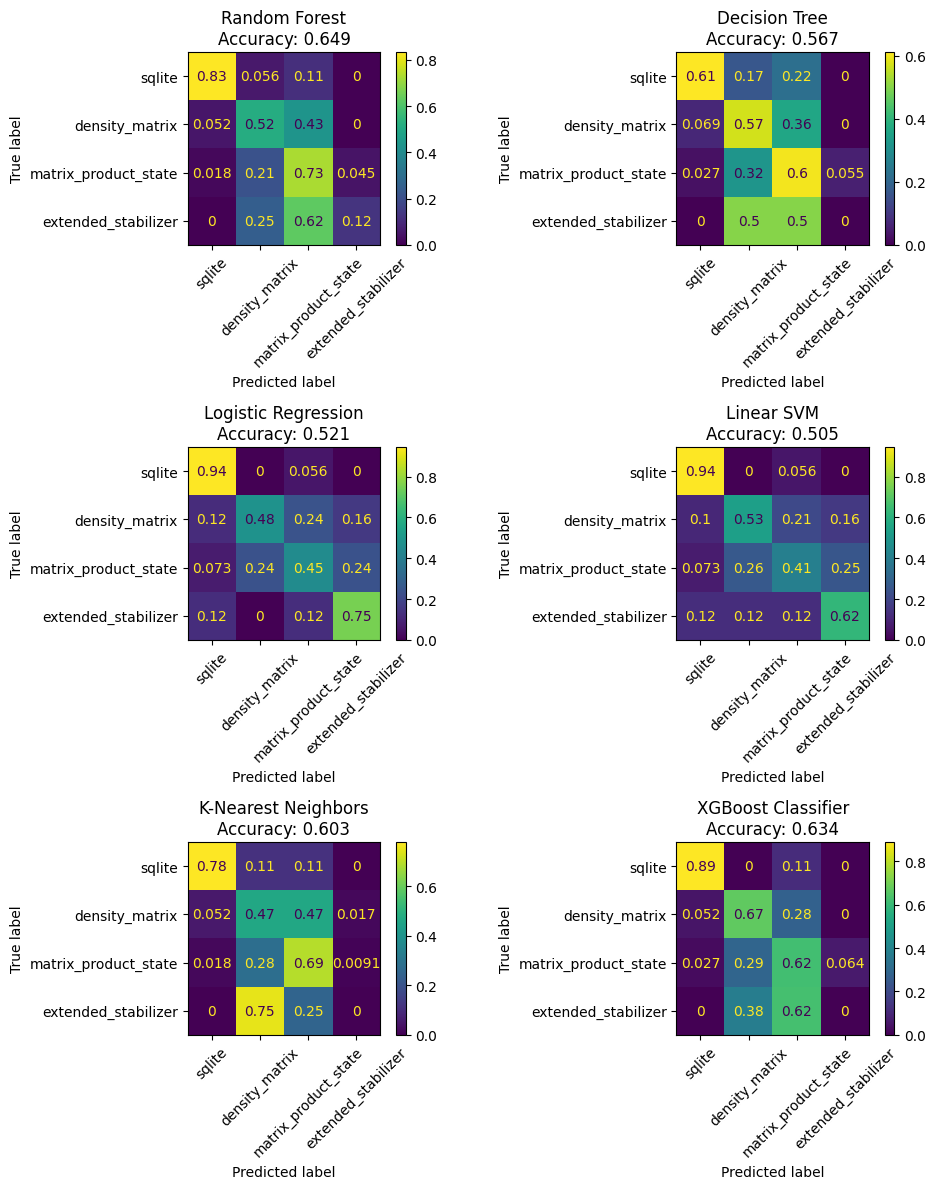

In [43]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from sklearn.utils.class_weight import compute_class_weight

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from utils import PlotConfusionReports
import numpy as np

# -------------------------------------------------
# 1. Build X and y
# -------------------------------------------------
X = df_with_qiskit[FEATURES]
y = df_with_qiskit["best_time_method"]   # string labels


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

# -------------------------------------------------
# 2. Label encoding (for XGBoost only)
# -------------------------------------------------
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc  = label_encoder.transform(y_test)

# -------------------------------------------------
# 3. Class weights (numeric + string)
# -------------------------------------------------
classes = np.unique(y_train)
class_weights = dict(
    zip(
        classes,
        compute_class_weight(
            class_weight="balanced",
            classes=classes,
            y=y_train
        )
    )
)

# numeric version for XGBoost
classes_enc = np.unique(y_train_enc)
class_weights_enc = dict(
    zip(
        classes_enc,
        compute_class_weight(
            class_weight="balanced",
            classes=classes_enc,
            y=y_train_enc
        )
    )
)

# per-sample weights for XGBoost
sample_weights_xgb = np.array([class_weights_enc[c] for c in y_train_enc])

# -------------------------------------------------
# 4. Define models (balanced where supported)
# -------------------------------------------------
models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    ),

    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            max_iter=2000,
            class_weight="balanced"
        ))
    ]),

    "Linear SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(
            kernel="linear",
            class_weight="balanced"
        ))
    ]),

    # KNN does NOT support class_weight
    "K-Nearest Neighbors": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier(n_neighbors=7))
    ]),

    # XGBoost: use sample_weight
    "XGBoost Classifier": XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softmax",
        num_class=len(label_encoder.classes_),
        eval_metric="mlogloss",
        random_state=42
    )
}

# -------------------------------------------------
# 5. Train + predict
# -------------------------------------------------
model_to_y_pred = {}

for name, model in models.items():

    if name == "XGBoost Classifier":
        model.fit(
            X_train,
            y_train_enc,
            sample_weight=sample_weights_xgb
        )
        y_pred_enc = model.predict(X_test)
        y_pred = label_encoder.inverse_transform(y_pred_enc)

    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    model_to_y_pred[name] = y_pred
    acc = accuracy_score(y_test, y_pred)
    print(f"{name:20s} accuracy = {acc:.3f}")

# -------------------------------------------------
# 6. Confusion matrices
# -------------------------------------------------
# PlotConfusionReports(y_test, model_to_y_pred, METHODS)
PlotConfusionReports(y_test, model_to_y_pred, ALL_METHODS) # with qiskit


Binary class distribution:
family
qiskit    704
rdbms      71
Name: count, dtype: int64

Binary classification results (RDBMS vs Qiskit):

Random Forest        accuracy = 0.933
              precision    recall  f1-score   support

      qiskit      0.955     0.972     0.963       176
       rdbms      0.667     0.556     0.606        18

    accuracy                          0.933       194
   macro avg      0.811     0.764     0.785       194
weighted avg      0.929     0.933     0.930       194

------------------------------------------------------------
Decision Tree        accuracy = 0.938
              precision    recall  f1-score   support

      qiskit      0.961     0.972     0.966       176
       rdbms      0.688     0.611     0.647        18

    accuracy                          0.938       194
   macro avg      0.824     0.791     0.807       194
weighted avg      0.935     0.938     0.936       194

------------------------------------------------------------
Logistic 

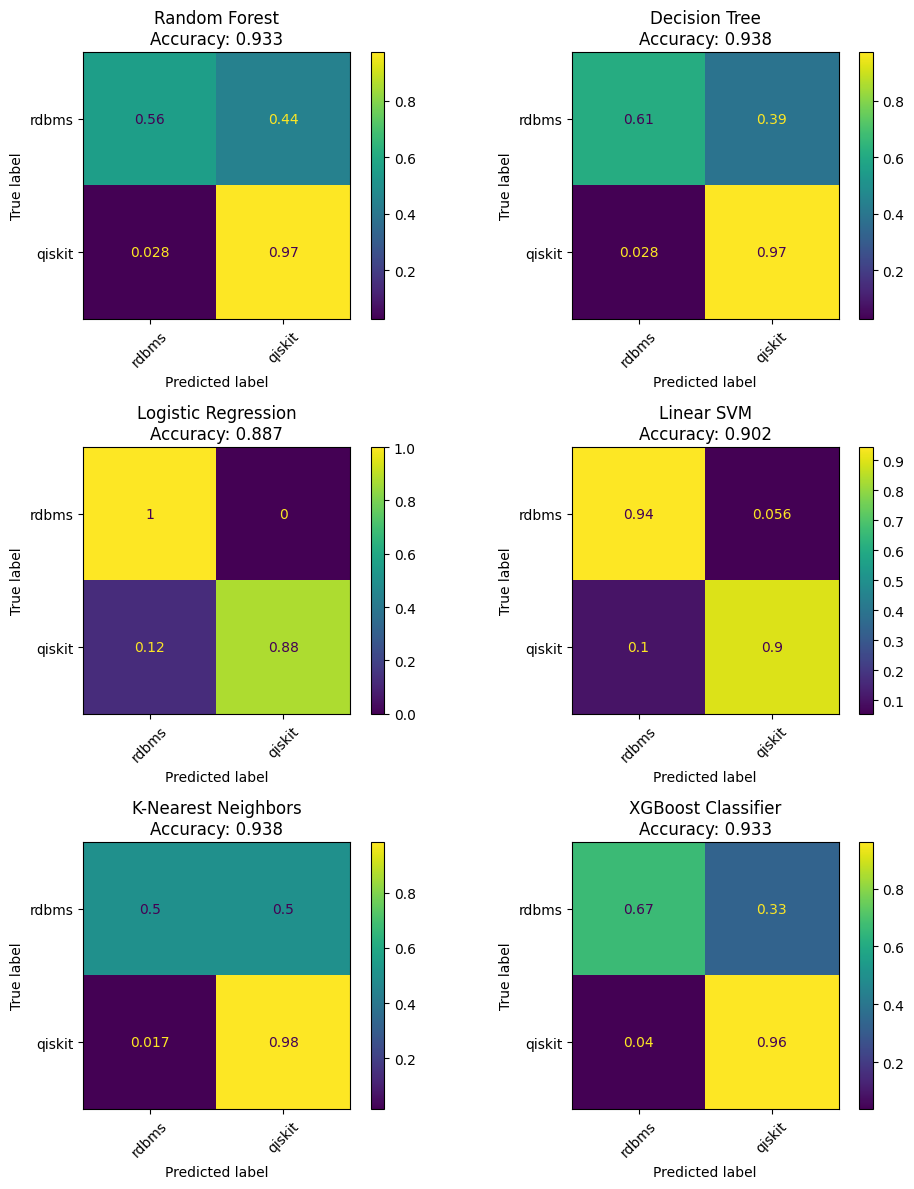

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report
from sklearn.utils.class_weight import compute_class_weight

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

import numpy as np

# -------------------------------------------------
# 1. Define method families
# -------------------------------------------------
RDBMS_METHODS = {
    "psql", "ducksql", "sqlite", "infiniquantum"
}

QISKIT_METHODS = {
    "statevector_saved",
    "density_matrix",
    "matrix_product_state",
    "extended_stabilizer",
}

# -------------------------------------------------
# 2. Build binary target
# -------------------------------------------------
def method_family(method):
    if method in RDBMS_METHODS:
        return "rdbms"
    if method in QISKIT_METHODS:
        return "qiskit"
    return np.nan

df_bin = df_with_qiskit.copy()
df_bin["family"] = df_bin["best_time_method"].apply(method_family)

# drop invalid rows
df_bin = df_bin.dropna(subset=["family"])

X = df_bin[FEATURES]
y = df_bin["family"]   # {"rdbms", "qiskit"}

print("Binary class distribution:")
print(y.value_counts())

# -------------------------------------------------
# 3. Train/test split
# -------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

# -------------------------------------------------
# 4. Encode labels (for XGBoost)
# -------------------------------------------------
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc  = label_encoder.transform(y_test)

# -------------------------------------------------
# 5. Class weights
# -------------------------------------------------
classes = np.unique(y_train)
class_weights = dict(
    zip(
        classes,
        compute_class_weight(
            class_weight="balanced",
            classes=classes,
            y=y_train
        )
    )
)

classes_enc = np.unique(y_train_enc)
class_weights_enc = dict(
    zip(
        classes_enc,
        compute_class_weight(
            class_weight="balanced",
            classes=classes_enc,
            y=y_train_enc
        )
    )
)

sample_weights_xgb = np.array([class_weights_enc[c] for c in y_train_enc])

# -------------------------------------------------
# 6. Models (binary)
# -------------------------------------------------
models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    ),

    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            max_iter=2000,
            class_weight="balanced"
        ))
    ]),

    "Linear SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(
            kernel="linear",
            class_weight="balanced"
        ))
    ]),

    "K-Nearest Neighbors": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier(n_neighbors=7))
    ]),

    "XGBoost Classifier": XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42
    )
}

# -------------------------------------------------
# 7. Train + evaluate
# -------------------------------------------------
print("\nBinary classification results (RDBMS vs Qiskit):\n")

for name, model in models.items():

    if name == "XGBoost Classifier":
        model.fit(
            X_train,
            y_train_enc,
            sample_weight=sample_weights_xgb
        )
        y_pred_enc = (model.predict(X_test) > 0.5).astype(int)
        y_pred = label_encoder.inverse_transform(y_pred_enc)

    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    print(f"{name:20s} accuracy = {acc:.3f}")
    print(classification_report(y_test, y_pred, digits=3))
    print("-" * 60)

# -------------------------------------------------
# 8. Collect predictions for plotting
# -------------------------------------------------
model_to_y_pred = {}

for name, model in models.items():

    if name == "XGBoost Classifier":
        model.fit(
            X_train,
            y_train_enc,
            sample_weight=sample_weights_xgb
        )
        y_pred_enc = (model.predict(X_test) > 0.5).astype(int)
        y_pred = label_encoder.inverse_transform(y_pred_enc)

    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    model_to_y_pred[name] = y_pred

# -------------------------------------------------
# 9. Confusion matrices (binary: RDBMS vs Qiskit)
# -------------------------------------------------
PlotConfusionReports(
    y_test,
    model_to_y_pred,
    methods=["rdbms", "qiskit"]
)


Top 15 most important features (Linear SVM):

                  feature  coefficient  abs_importance
1         num_and_clauses    -2.059051        2.059051
0           num_agg_funcs    -1.065907        1.065907
4           num_group_bys    -1.065907        1.065907
5    num_join_occurrences    -0.820352        0.820352
3       num_eq_predicates    -0.820352        0.820352
7   num_unique_join_edges     0.508257        0.508257
6               num_joins     0.508257        0.508257
10      num_where_clauses    -0.186030        0.186030
9      num_select_columns    -0.115819        0.115819
2     num_subqueries_with     0.000000        0.000000
8           num_order_bys     0.000000        0.000000


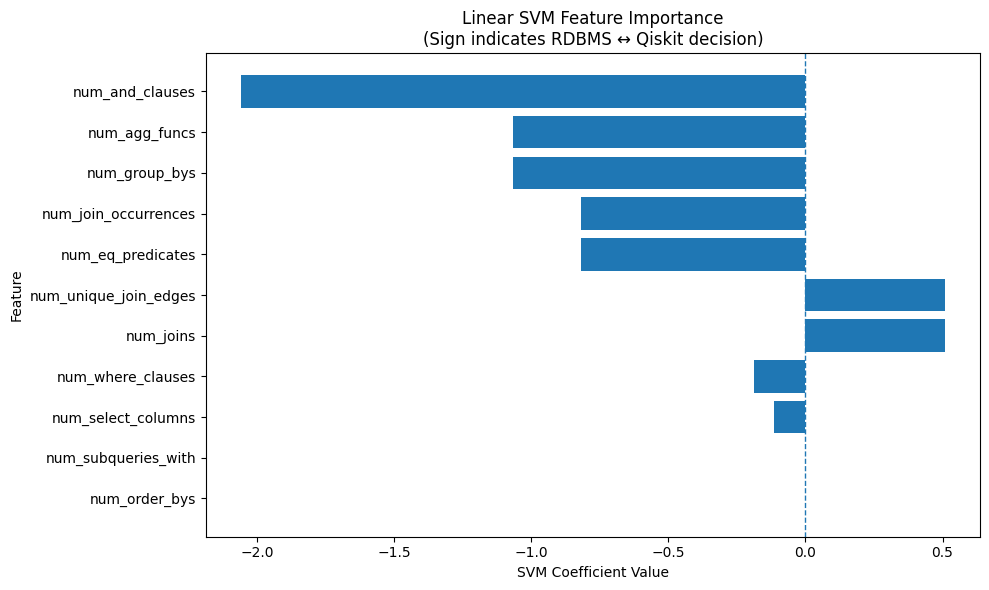


Interpretation:
• Positive coefficient  → pushes prediction toward class 'qiskit'
• Negative coefficient  → pushes prediction toward class 'rdbms'
• Larger magnitude      → stronger influence on decision


In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------
# 1. Get trained Linear SVM from pipeline
# -------------------------------------------------
svm_pipeline = models["Linear SVM"]
svm_clf = svm_pipeline.named_steps["clf"]
scaler = svm_pipeline.named_steps["scaler"]

# -------------------------------------------------
# 2. Get feature names and coefficients
# -------------------------------------------------
feature_names = FEATURES
coefs = svm_clf.coef_.ravel()   # binary SVM → shape (n_features,)

importance_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefs,
    "abs_importance": np.abs(coefs)
})

# Sort by absolute importance
importance_df = importance_df.sort_values(
    "abs_importance",
    ascending=False
)

# -------------------------------------------------
# 3. Print top features
# -------------------------------------------------
print("Top 15 most important features (Linear SVM):\n")
print(importance_df.head(15))

# -------------------------------------------------
# 4. Visualize decision surface (top-k features)
# -------------------------------------------------
TOP_K = 20
plot_df = importance_df.head(TOP_K).iloc[::-1]  # reverse for plotting

plt.figure(figsize=(10, 6))
plt.barh(
    plot_df["feature"],
    plot_df["coefficient"]
)

plt.axvline(0, linestyle="--", linewidth=1)
plt.title("Linear SVM Feature Importance\n(Sign indicates RDBMS ↔ Qiskit decision)")
plt.xlabel("SVM Coefficient Value")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

# -------------------------------------------------
# 5. Interpretation helper
# -------------------------------------------------
print("\nInterpretation:")
print("• Positive coefficient  → pushes prediction toward class 'qiskit'")
print("• Negative coefficient  → pushes prediction toward class 'rdbms'")
print("• Larger magnitude      → stronger influence on decision")
